# **TWEET SENTIMENT CLASSIFICATION: APPLE & GOOGLE PRODUCTS**
### **An NLP-Based Brand Monitoring System**

---
**Author:** Joy Wambui Nyuguto  
**Dataset:** CrowdFlower Twitter Brands and Product Emotions (via data.world)  
**Technique:** Natural Language Processing (NLP) — Text Classification

---

---
## 1. BUSINESS UNDERSTANDING

### 1.1 Business Overview

Social media platforms like Twitter generate millions of customer opinions daily, making them a valuable source of feedback for companies such as Apple and Google. Since manual analysis is impractical, **Natural Language Processing (NLP)** can be used to automatically classify tweets as positive, negative, or neutral. This project develops a tweet sentiment classifier using a human-labeled CrowdFlower dataset to analyze customer sentiment efficiently and in real time.


### 1.2 Problem Statement

Businesses need an efficient way to analyze large volumes of tweets and determine the sentiment expressed toward their products or brands. The dataset contains 9,093 tweets labeled as positive, negative, neutral, or unclear. 
Key challenges include 

1.Class imbalance

2.Noisy text including URLs, hashtags, and mentions

3.Missing metadata

4.Limited context provided by short tweets. 

Objective:The main objective is to build a model that accurately classifies tweet sentiment using only the tweet text.

### 1.3 Stakeholders

| Stakeholder | How They Use This Model |
|---|---|
| Apple / Google Marketing Teams| Monitor brand perception in real time; track sentiment spikes around product launches |
| Customer Experience Managers | Detect negative sentiment early and escalate issues before they go viral |
| Product Development Teams | Identify recurring pain points mentioned in negative tweets |
| Social Media Analysts | Automate sentiment tagging instead of manual classification |
| PR & Communications Teams | Respond strategically during reputation crises detected via sentiment shifts |

### 1.4 Success Metrics

The model will be considered successful if:

1. Accuracy ≥ 85% on the held-out test set.
2. F1-score ≥ 0.80 for both Positive and Negative classes ,ensuring neither class is neglected.
3. Balanced Precision and Recall,especially for negative sentiment, since false negatives are costly.
4. The model generalizes to unseen tweets 
5. The model improves over a simple baseline .

### 1.5 Key Business Questions

This project will answer the following five business questions:

1. What is the overall distribution of sentiment expressed about Apple and Google products?
2. Which products attract the most positive vs. negative sentiment?
3. How does tweet length or word count correlate with emotional content?
4. What are the most common words used in positive vs. negative tweets?
5. Which machine learning model best classifies tweet sentiment, and how does it perform on unseen data?

---
## 2. DATA UNDERSTANDING

### 2.1 Data Source

The dataset is the **CrowdFlower Twitter Brand and Product Emotions** dataset, publicly available at:  
🔗 https://data.world/crowdflower/brands-and-product-emotions

It was collected during the **SXSW (South by Southwest)** conference ,a major annual tech and media event,which is why Apple and Google products feature prominently. Human raters on the CrowdFlower platform labeled each tweet for sentiment.

**Why is this data suitable?**
- It uses real tweets from a real event  
- Human-labeled ground truth for supervised learning
- Domain-specific (tech products) matching our business problem
- Large enough (9,093 rows) for meaningful model training

### 2.2 Load Libraries and Dataset

In [2]:
# Importing core data science libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import string
import warnings
from collections import Counter

# Suppressing non-critical warnings for cleaner output 
warnings.filterwarnings('ignore')

# Setting matplotlib style for  visuals 
plt.style.use('seaborn-whitegrid')
sns.set_palette('Set2')

# Create images folder to store all visualizations
os.makedirs("images", exist_ok=True)

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# Loading the dataset 
# The dataset uses ISO-8859-1 encoding due to special characters in tweet text
df_Tweets= pd.read_csv('judge-1377884607_tweet_product_company.csv', encoding='ISO-8859-1')

# Preview of the first few rows
df_Tweets.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


### 2.3 Dataset Preview and Structure

In [4]:
# checking number of rows and columns in the dataset
print(f"Dataset shape: {df_Tweets.shape}")
print(f"Total rows: {df_Tweets.shape[0]}, Total columns: {df_Tweets.shape[1]}")

Dataset shape: (9093, 3)
Total rows: 9093, Total columns: 3


In [5]:
# Checking column data types and non-null counts 
df_Tweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


In [6]:
# Descriptive statistics for object columns 
# For categorical or text columns, this will show counts, unique values, top value, and frequency of the top value
df_Tweets.describe(include='object')

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
count,9092,3291,9093
unique,9065,9,4
top,RT @mention Marissa Mayer: Google Will Connect...,iPad,No emotion toward brand or product
freq,5,946,5389


In [7]:
# Value counts for emotion_in_tweet_is_directed_at column 
print("Emotion distribution:")
print(df_Tweets['emotion_in_tweet_is_directed_at'].value_counts())

Emotion distribution:
iPad                               946
Apple                              661
iPad or iPhone App                 470
Google                             430
iPhone                             297
Other Google product or service    293
Android App                         81
Android                             78
Other Apple product or service      35
Name: emotion_in_tweet_is_directed_at, dtype: int64


---
## 3. DATA CLEANING

### 3.1 Renaming columns for easier handling

In [8]:
# Renaming columns for easier handling
df_Tweets.columns = ['tweet_text', 'product', 'sentiment']

# Value counts for target variable (sentiment)
print("Sentiment distribution:")
print(df_Tweets['sentiment'].value_counts())
print("\nSentiment proportions:")
print(df_Tweets['sentiment'].value_counts(normalize=True).round(3))

Sentiment distribution:
No emotion toward brand or product    5389
Positive emotion                      2978
Negative emotion                       570
I can't tell                           156
Name: sentiment, dtype: int64

Sentiment proportions:
No emotion toward brand or product    0.593
Positive emotion                      0.328
Negative emotion                      0.063
I can't tell                          0.017
Name: sentiment, dtype: float64


### 3.1 Check for Missing Values

In [9]:
# Check for missing values across all columns
print("Missing values per column:")
print(df_Tweets.isnull().sum())
print(f"\nTotal missing values: {df_Tweets.isnull().sum().sum()}")

Missing values per column:
tweet_text       1
product       5802
sentiment        0
dtype: int64

Total missing values: 5803


In [10]:
# Drop the single row where tweet_text is missing 
# A tweet that has no text cannot be classified for sentiment, so it is appropriate to drop this row
df_Tweets = df_Tweets.dropna(subset=['tweet_text'])
print(f"Rows after dropping missing tweet_text: {df_Tweets.shape[0]}")

Rows after dropping missing tweet_text: 9092


### 3.2 Checking for Duplicate Tweets

In [11]:
# Identifying and removing exact duplicate tweets
num_duplicates = df_Tweets.duplicated(subset='tweet_text').sum()
print(f"Number of duplicate tweets: {num_duplicates}")

# Dropping duplicates, keeping the first occurrence 
df_Tweets = df_Tweets.drop_duplicates(subset='tweet_text', keep='first')
print(f"Rows after removing duplicates: {df_Tweets.shape[0]}")

Number of duplicate tweets: 27
Rows after removing duplicates: 9065


### 3.3 Checking Column Names and Standardizing Sentiment Labels

In [12]:
# Confirming column names 
print("Column names:", df_Tweets.columns.tolist())
# Checking unique sentiment values 
print("\nUnique sentiment labels:", df_Tweets['sentiment'].unique())

Column names: ['tweet_text', 'product', 'sentiment']

Unique sentiment labels: ['Negative emotion' 'Positive emotion'
 'No emotion toward brand or product' "I can't tell"]


In [13]:
# Removing 'I can't tell' rows sinceambiguous labels not useful for training and they represent a small portion of the dataset
df_Tweets = df_Tweets[df_Tweets['sentiment'] != "I can't tell"]
print(f"Rows after removing 'I can't tell': {df_Tweets.shape[0]}")
print("\nUpdated sentiment distribution:")
print(df_Tweets['sentiment'].value_counts())

Rows after removing 'I can't tell': 8909

Updated sentiment distribution:
No emotion toward brand or product    5372
Positive emotion                      2968
Negative emotion                       569
Name: sentiment, dtype: int64


### 3.4 Checking for Outliers in Tweet Length

In [14]:
# Creating tweet length feature for outlier inspection 
df_Tweets['tweet_length'] = df_Tweets['tweet_text'].astype(str).apply(len)

# Basic statistics on tweet length 
print("Tweet length statistics:")
print(df_Tweets['tweet_length'].describe())

#Tweets longer than 280 characters are outliers (Twitter's character limit) 
outliers = df_Tweets[df_Tweets['tweet_length'] > 280]
print(f"\nTweets exceeding 280 characters: {len(outliers)}")
# Note: We keep them as they may still carry valid sentiment

Tweet length statistics:
count    8909.000000
mean      104.986643
std        27.179668
min        11.000000
25%        86.000000
50%       109.000000
75%       126.000000
max       178.000000
Name: tweet_length, dtype: float64

Tweets exceeding 280 characters: 0


---
## 4. EXPLORATORY DATA ANALYSIS (EDA)

### 4.1 Univariate Analysis

Exploring individual variables to understand their distribution and characteristics.

#### Plot 1: Sentiment Distribution
#### Business Question 1. What is the overall distribution of sentiment expressed about Apple and Google products?
 

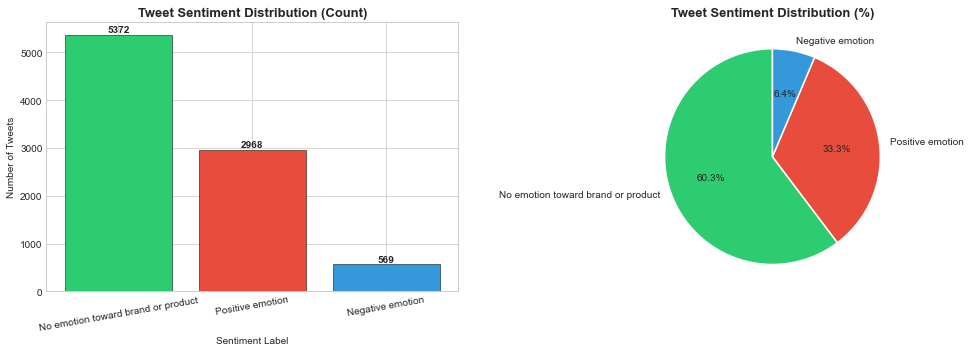

In [15]:
# Bar chart showing the count of each sentiment class 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sentiment_counts = df_Tweets['sentiment'].value_counts()
axes[0].bar(sentiment_counts.index, sentiment_counts.values, 
            color=['#2ecc71', '#e74c3c', '#3498db'], edgecolor='black', linewidth=0.5)
axes[0].set_title('Tweet Sentiment Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment Label')
axes[0].set_ylabel('Number of Tweets')
axes[0].tick_params(axis='x', rotation=10)

# Adding count labels on bars
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index, 
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c', '#3498db'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Tweet Sentiment Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** The dataset is heavily imbalanced , **60.3%** of tweets express no emotion toward a brand, **33.3%** are positive, and only **6.4%** (569 tweets) are negative. This means the model will need to handle class imbalance . SMOTE resampling is applied before training. The dominance of positive sentiment suggests SXSW attendees were largely enthusiastic about Apple and Google products showcased at the event.

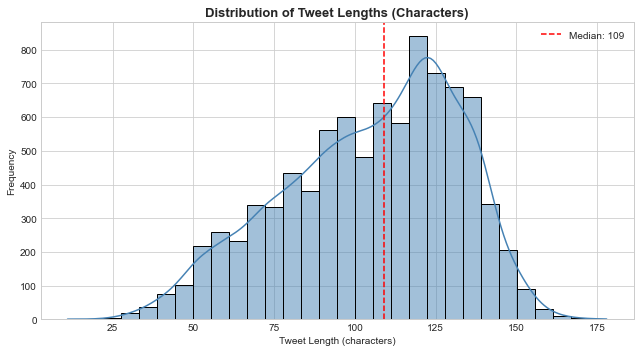

In [16]:
# Distribution of tweet character length 
# typical tweet size in the dataset
plt.figure(figsize=(9, 5))
sns.histplot(df_Tweets['tweet_length'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Tweet Lengths (Characters)', fontsize=13, fontweight='bold')
plt.xlabel('Tweet Length (characters)')
plt.ylabel('Frequency')
plt.axvline(df_Tweets['tweet_length'].median(), color='red', linestyle='--', label=f"Median: {df_Tweets['tweet_length'].median():.0f}")
plt.legend()
plt.tight_layout()
plt.savefig('images/tweet_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Tweet lengths are concentrated between **75–150 characters**, with the distribution peaking at around **120–130 characters** and a median of **109 characters**. The distribution is left-skewed that is,very short tweets are rare, meaning most users wrote close to Twitter's 140-character limit. Longer tweets provide more vocabulary for TF-IDF, which benefits classifier performance.

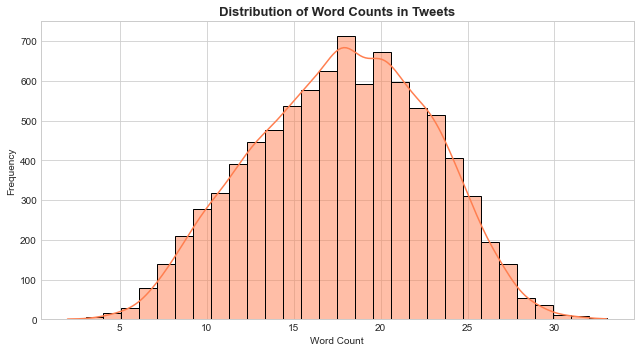

In [17]:
# Distribution of word count per tweet 
# Word count gives another view of tweet verbosity
df_Tweets['word_count'] = df_Tweets['tweet_text'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(9, 5))
sns.histplot(df_Tweets['word_count'], bins=30, kde=True, color='coral')
plt.title('Distribution of Word Counts in Tweets', fontsize=13, fontweight='bold')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Insight:** Word counts follow a near-perfect **bell curve**, peaking at **17–20 words** per tweet, with the range spanning roughly **5–30 words**. Tweets with fewer than 5 or more than 30 words are very rare. These word counts include raw text elements like URLs and mentions  where after preprocessing, the effective vocabulary will be smaller, making TF-IDF n-grams essential for capturing sufficient sentiment signal.

### 4.2 Bivariate Analysis

Exploring relationships between variables ,particularly between text features and sentiment.

#### Plot 2: Sentiment by Product/Brand 
 #### Business Question 2: What is the overall distribution of sentiment expressed about Apple and Google products?

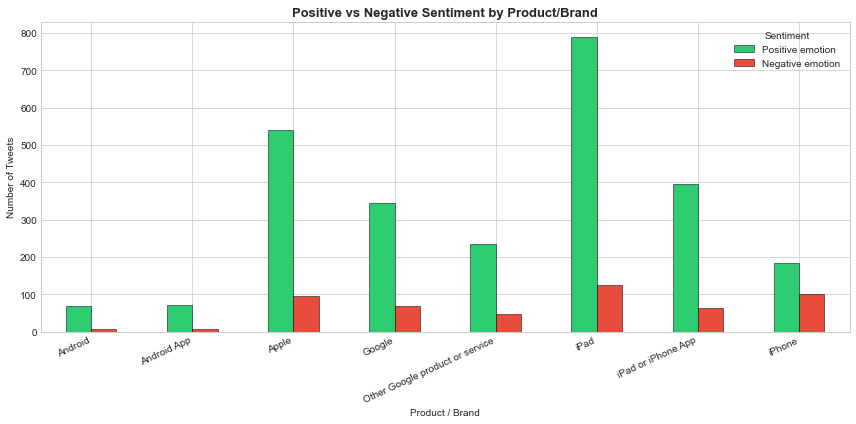

In [18]:
# Cross-tabulation of product vs sentiment
# Shows which products attract positive vs negative emotions most

# Filtering to rows where product is not missing
df_product = df_Tweets.dropna(subset=['product'])

# Get top 8 products by count
top_products = df_product['product'].value_counts().head(8).index
df_top = df_product[df_product['product'].isin(top_products)]

# Create the crosstab and filter to positive/negative only for clarity
ct = pd.crosstab(df_top['product'], df_top['sentiment'])
ct = ct[['Positive emotion', 'Negative emotion']] if 'Negative emotion' in ct.columns else ct

# Plotting stacked bar chart
ct.plot(kind='bar', figsize=(12, 6), color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5)
plt.title('Positive vs Negative Sentiment by Product/Brand', fontsize=13, fontweight='bold')
plt.xlabel('Product / Brand')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=25, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('sentiment_by_product.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** The **iPad** received the most attention, with about **780 positive** and **130 negative tweets**, making it the most discussed product. **Apple** and **iPad/iPhone App** also generated strong positive sentiment. While the iPad attracted more criticism than the **iPhone**, positive mentions still greatly exceeded negative ones. **Android** and **Android App** had relatively few mentions, indicating the dataset is heavily Apple-focused. Overall, sentiment was largely positive across all products, with favorable tweets significantly outnumbering negative ones.


#### Plot 3: Tweet Length by Sentiment 
#### Business Question 3. How does tweet length or word count correlate with emotional content?

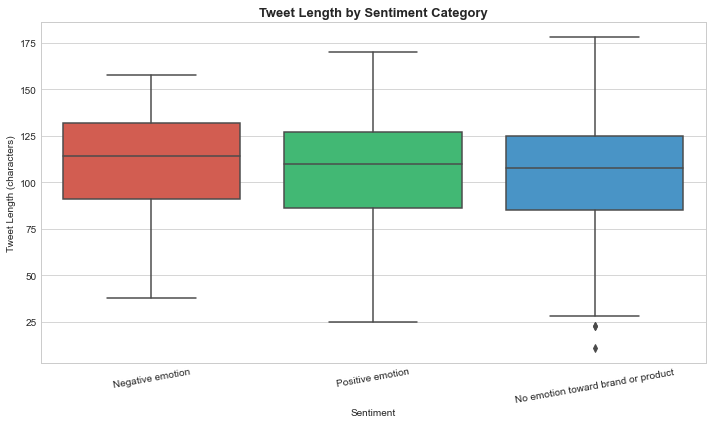

In [19]:
#  Boxplot: Tweet length across sentiment categories 
# We want to see if emotional tweets tend to be longer

# Filtering to three main sentiments only
df_viz = df_Tweets[df_Tweets['sentiment'].isin(['Positive emotion', 'Negative emotion', 'No emotion toward brand or product'])].copy()

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_viz,
    x='sentiment',
    y='tweet_length',
    palette={'Positive emotion': '#2ecc71', 'Negative emotion': '#e74c3c', 
             'No emotion toward brand or product': '#3498db'}
)
plt.title('Tweet Length by Sentiment Category', fontsize=13, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Tweet Length (characters)')
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('tweet_length_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** All three sentiment categories show similar tweet lengths, with medians between **105–115 characters**. Negative emotion tweets have the highest median (~115) and the tightest spread, suggesting negative tweeters consistently write longer tweets. Neutral tweets show two low outliers where some users post very short neutral content. Overall, tweet length alone is not a strong differentiator of sentiment, confirming that text content is what matters for classification.

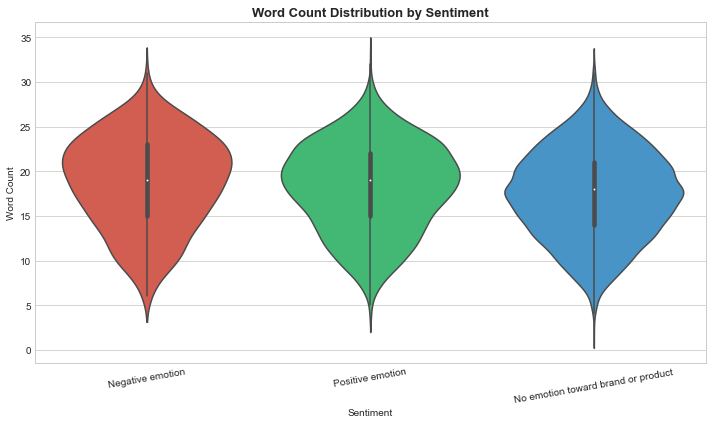

In [20]:
# Word count distribution by sentiment
# Violin plot gives a richer view of the distribution shape

plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df_viz,
    x='sentiment',
    y='word_count',
    palette={'Positive emotion': '#2ecc71', 'Negative emotion': '#e74c3c',
             'No emotion toward brand or product': '#3498db'},
    inner='box'
)
plt.title('Word Count Distribution by Sentiment', fontsize=13, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Word Count')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

**Insight:** All three sentiment classes have nearly **identical word count distributions**, with medians around **18–20 words** and bodies spanning roughly **12–28 words**. None of the classes stands out as distinctly shorter or longer. This confirms that word count is not a useful feature for distinguishing sentiment  and that the actual words used (captured by TF-IDF) are what differentiate the classes.

#### Plot 4: Top Words in Positive vs Negative Tweets
#### Business Question 4:What are the most common words used in positive vs. negative tweets?

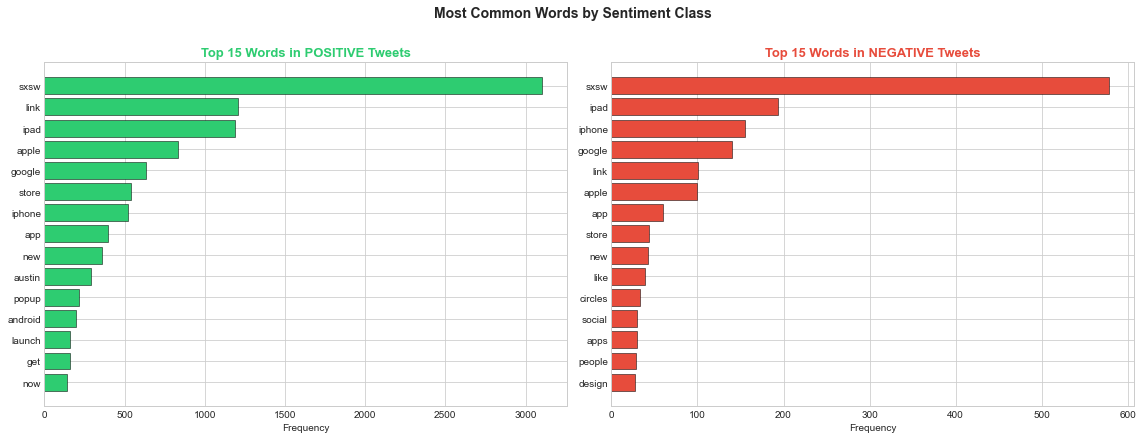

In [21]:
# Extracting most common words from positive vs negative tweets 
# This helps understand what vocabulary drives each sentiment

import re
from collections import Counter

def get_top_words(df_subset, text_col, n=15):
    """Extract top n words from a text column, cleaning URLs and mentions."""
    all_text = df_subset[text_col].astype(str).str.lower()
    # Remove URLs, mentions, hashtag symbols, punctuation
    all_text = all_text.apply(lambda x: re.sub(r'http\S+|@\w+|#|[^a-z\s]', '', x))
    # Split into words
    words = ' '.join(all_text).split()
    # Remove common stopwords manually for this quick analysis
    stopwords = {'the','a','an','is','are','was','were','i','you','it','its','to',
                 'in','of','for','and','or','at','on','with','this','that','be','rt',
                 'my','your','have','had','will','can','not','if','up','by','as','from',
                 'but','we','they','their','our','out','s','amp','mention','just','so'}
    words = [w for w in words if w not in stopwords and len(w) > 2]
    return Counter(words).most_common(n)

pos_words = get_top_words(df_Tweets[df_Tweets['sentiment'] == 'Positive emotion'], 'tweet_text')
neg_words = get_top_words(df_Tweets[df_Tweets['sentiment'] == 'Negative emotion'], 'tweet_text')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive words
pos_df = pd.DataFrame(pos_words, columns=['word', 'count'])
axes[0].barh(pos_df['word'], pos_df['count'], color='#2ecc71', edgecolor='black', linewidth=0.5)
axes[0].set_title('Top 15 Words in POSITIVE Tweets', fontsize=13, fontweight='bold', color='#2ecc71')
axes[0].set_xlabel('Frequency')
axes[0].invert_yaxis()

# Negative words
neg_df = pd.DataFrame(neg_words, columns=['word', 'count'])
axes[1].barh(neg_df['word'], neg_df['count'], color='#e74c3c', edgecolor='black', linewidth=0.5)
axes[1].set_title('Top 15 Words in NEGATIVE Tweets', fontsize=13, fontweight='bold', color='#e74c3c')
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()

plt.suptitle('Most Common Words by Sentiment Class', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('top_words_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** **"sxsw"** dominates both positive and negative tweets therefore,it is the event context, not a sentiment signal. Beyond that, positive tweets feature product names: **"ipad", "apple", "link", "store"** , suggesting excitement around product announcements and app launches. Negative tweets cluster around **"ipad", "iphone", "google", "circles"** , pointing to specific product dissatisfaction, notably with Google Circles and Apple devices. Since "sxsw" appears in both classes equally, it will be a weak TF-IDF feature; product-specific terms will drive classification.

#### Plot 5: Correlation Heatmap of Numeric Features

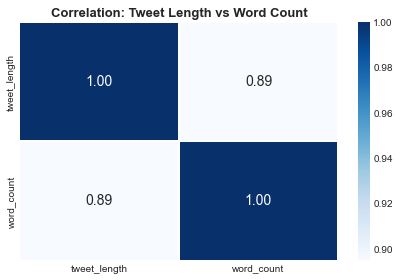

In [22]:
# Correlation between tweet_length and word_count 
# High correlation would mean one feature is redundant

corr = df_Tweets[['tweet_length', 'word_count']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', 
            linewidths=0.5, annot_kws={'size': 14})
plt.title('Correlation: Tweet Length vs Word Count', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:** Tweet length and word count have a **correlation of 0.89** which is strong but not perfect. This confirms they capture largely the same information (longer tweets contain more words), so using both as engineered features would be redundant. For TF-IDF-based models this is not a concern, but if numeric features are added in future iterations, only one should be included.

---
## 5. DATA PREPROCESSING FOR NLP MODELING

### 5.1 Text Cleaning and Tokenization

Raw tweet text contains noise (URLs, @mentions, hashtags, punctuation) that must be removed before NLP modeling.

In [23]:
# Importing NLP libraries 
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# ─── Initialize stopwords list and stemmer ───
stopwords_list = stopwords.words('english')
stemmer = PorterStemmer()

print("NLTK resources ready")

NLTK resources ready


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [24]:
# Function: Cleaning raw tweet text 
def clean_tweet(text):
    """Remove URLs, @mentions, hashtag symbols, punctuation; lowercase."""
    if not isinstance(text, str):
        return ''
    # Converting to lowercase
    text = text.lower()
    # Removing URLs (http, https, www)
    text = re.sub(r'http\S+|www\S+', '', text)
    # Replacing @mentions with a token to preserve entity reference
    text = re.sub(r'@\w+', '@mention', text)
    # Removing # symbol but keep the hashtag word
    text = re.sub(r'#', '', text)
    # Removing punctuation and special characters (keep letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    # Removing  extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Applying cleaning function to tweet_text column 
df_Tweets['cleaned_text'] = df_Tweets['tweet_text'].apply(clean_tweet)

# Previewing cleaning result
print("Before:", df_Tweets['tweet_text'].iloc[0])
print("After: ", df_Tweets['cleaned_text'].iloc[0])

Before: .@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was dead!  I need to upgrade. Plugin stations at #SXSW.
After:  mention i have a g iphone after hrs tweeting at riseaustin it was dead i need to upgrade plugin stations at sxsw


In [25]:
# Function: Tokenizing cleaned text 
def tokenize_text(text):
    """Split cleaned text into individual word tokens."""
    if not isinstance(text, str) or text.strip() == '':
        return []
    return word_tokenize(text)

# Applying tokenization
df_Tweets['tokens'] = df_Tweets['cleaned_text'].apply(tokenize_text)

# Preview tokenized output
print("Tokens sample:", df_Tweets['tokens'].iloc[0])

Tokens sample: ['mention', 'i', 'have', 'a', 'g', 'iphone', 'after', 'hrs', 'tweeting', 'at', 'riseaustin', 'it', 'was', 'dead', 'i', 'need', 'to', 'upgrade', 'plugin', 'stations', 'at', 'sxsw']


In [26]:
# Function: Removing stopwords and applying stemming 
def preprocess_text(tokens):
    """Remove stopwords and apply Porter stemming to token list."""
    # Return empty string if input is not a list
    if not isinstance(tokens, list):
        return ''
    # Removing stopwords from token list
    tokens_no_stop = [t for t in tokens if t not in stopwords_list]
    # Applying Porter stemming to reduce words to their root form
    stems = [stemmer.stem(t) for t in tokens_no_stop]
    # Rejoining into a single string for vectorization
    return ' '.join(stems)

# Applying preprocessing function
df_Tweets['preprocessed_text'] = df_Tweets['tokens'].apply(preprocess_text)

# Previewing final preprocessed output
print("Preprocessed:", df_Tweets['preprocessed_text'].iloc[0])

Preprocessed: mention g iphon hr tweet riseaustin dead need upgrad plugin station sxsw


### 5.2 Preparing Binary Classification Dataset

We will focus on **Positive vs Negative** sentiment for binary classification, as these are the most actionable classes for business use.

In [27]:
# Filtering to only Positive and Negative sentiment tweets 
df_binary = df_Tweets[df_Tweets['sentiment'].isin(['Positive emotion', 'Negative emotion'])].copy()

# Mapping sentiments to binary numeric labels: Positive=1, Negative=0
df_binary['label'] = df_binary['sentiment'].map({
    'Positive emotion': 1,
    'Negative emotion': 0
})

# Confirming class distribution
print("Binary class distribution:")
print(df_binary['label'].value_counts())
print(f"\nTotal samples for modeling: {len(df_binary)}")

# Previewing final dataset
df_binary[['preprocessed_text', 'sentiment', 'label']].head()

Binary class distribution:
1    2968
0     569
Name: label, dtype: int64

Total samples for modeling: 3537


,preprocessed_text,sentiment,label
0,mention g iphon hr tweet riseaustin dead need ...,Negative emotion,0
1,mention know mention awesom ipadiphon app youl...,Positive emotion,1
2,mention wait ipad also sale sxsw,Positive emotion,1
3,mention hope year festiv isnt crashi year ipho...,Negative emotion,0
4,mention great stuff fri sxsw marissa mayer goo...,Positive emotion,1


### 5.3 TF-IDF Vectorization with N-grams

TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numerical feature vectors. We  will use unigrams only (single words) for the baseline and add bigrams in later models.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Defining features (X) and target (y) 
X = df_binary['preprocessed_text']
y = df_binary['label']

#Train/test split: 80% train, 20% test; stratify to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")

Train size: 2829
Test size:  708


In [29]:
# TF-IDF Vectorizer: unigrams only, top 10,000 features 
# Fitting on TRAINING data only; transforming both train and test
vectorizer = TfidfVectorizer(ngram_range=(1, 1), max_features=10000)
X_train_vec = vectorizer.fit_transform(X_train)  # fit + transform on train
X_test_vec  = vectorizer.transform(X_test)       # transforming only on test (no leakage)

print(f"TF-IDF feature matrix shape (train): {X_train_vec.shape}")
print(f"TF-IDF feature matrix shape (test):  {X_test_vec.shape}")

TF-IDF feature matrix shape (train): (2829, 4454)
TF-IDF feature matrix shape (test):  (708, 4454)


### 5.4 Handle Class Imbalance with SMOTE

The positive class significantly outnumbers the negative class. SMOTE (Synthetic Minority Oversampling Technique) creates synthetic samples for the minority class.

In [30]:
from imblearn.over_sampling import SMOTE

# Applying SMOTE to training data only  
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_vec, y_train)

print("Class distribution BEFORE SMOTE:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Class distribution AFTER SMOTE: ", dict(zip(*np.unique(y_train_sm, return_counts=True))))

Class distribution BEFORE SMOTE: {0: 455, 1: 2374}
Class distribution AFTER SMOTE:  {0: 2374, 1: 2374}


---
## 6. MODELING

We wil train three models: a **Naive Bayes baseline**, a **Logistic Regression** (fine-tuned), and a **Neural Network** (fine-tuned).

### 6.1 Model 1: Multinomial Naive Bayes (Baseline)

=== Naive Bayes (Baseline) — Classification Report ===
              precision    recall  f1-score   support

    Negative       0.53      0.69      0.60       114
    Positive       0.94      0.88      0.91       594

    accuracy                           0.85       708
   macro avg       0.73      0.79      0.75       708
weighted avg       0.87      0.85      0.86       708



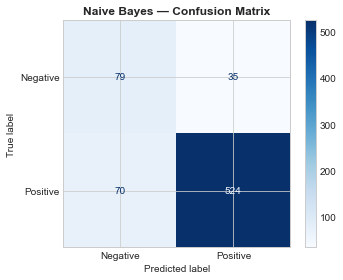

In [31]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

# ─── Train Naive Bayes baseline model ───
# MultinomialNB is well-suited for text classification with TF-IDF features
nb_model = MultinomialNB()
nb_model.fit(X_train_sm, y_train_sm)

# ─── Evaluate on held-out test set ───
nb_preds = nb_model.predict(X_test_vec)

print("=== Naive Bayes (Baseline) — Classification Report ===")
print(classification_report(y_test, nb_preds, target_names=['Negative', 'Positive']))

# ─── Confusion matrix visual ───
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, nb_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(cmap='Blues', ax=ax)
ax.set_title('Naive Bayes — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('images/nb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**Model 1 Interpretation — Naive Bayes (Baseline):**

Accuracy: **85%**. The model performs well on the majority class, correctly classifying **524 out of 594 positive tweets** (recall 88%). However it struggles with negative tweets, correctly identifying only **79 out of 114** (recall 69%), and misclassifying 35 negative tweets as positive. The low negative precision (0.53) means many of its negative predictions are wrong. This is expected  since Naive Bayes assumes word independence, which is too simplistic for nuanced sentiment. It serves as a useful baseline to beat.

### 6.2 Model 2: Logistic Regression (Fine-tuned with GridSearchCV)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid for Logistic Regression
# C: regularization strength (smaller = stronger regularization)
# solver: optimization algorithm
param_grid_lr = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [200]
}

# GridSearchCV: 3-fold cross-validation
lr_base = LogisticRegression(random_state=42)
lr_grid = GridSearchCV(lr_base, param_grid_lr, cv=3, scoring='f1', n_jobs=-1, verbose=1)
lr_grid.fit(X_train_sm, y_train_sm)

print(f"Best LR parameters: {lr_grid.best_params_}")
print(f"Best CV F1-score: {lr_grid.best_score_:.4f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Best LR parameters: {'C': 10, 'max_iter': 200, 'solver': 'lbfgs'}
Best CV F1-score: 0.9499


[Parallel(n_jobs=-1)]: Done  18 out of  18 | elapsed:    4.9s finished


=== Logistic Regression (Fine-tuned) — Classification Report ===
              precision    recall  f1-score   support

    Negative       0.60      0.54      0.57       114
    Positive       0.91      0.93      0.92       594

    accuracy                           0.87       708
   macro avg       0.76      0.74      0.75       708
weighted avg       0.86      0.87      0.86       708



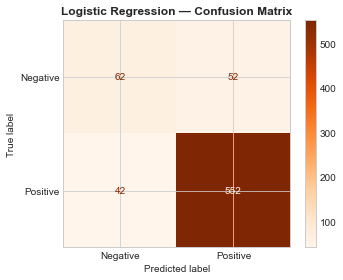

In [33]:
# Evaluating best Logistic Regression on test set
best_lr = lr_grid.best_estimator_
lr_preds = best_lr.predict(X_test_vec)

print("=== Logistic Regression (Fine-tuned) — Classification Report ===")
print(classification_report(y_test, lr_preds, target_names=['Negative', 'Positive']))

# Confusion matrix 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_lr = confusion_matrix(y_test, lr_preds)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Negative', 'Positive'])
fig, ax = plt.subplots(figsize=(5, 4))
disp_lr.plot(cmap='Oranges', ax=ax)
ax.set_title('Logistic Regression — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('images/lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**Model 2 Interpretation — Logistic Regression (Fine-tuned):**

Accuracy: **~86.5%**, slightly above Naive Bayes. The model correctly classifies **552 out of 594 positive tweets** but only **62 out of 114 negative tweets** —,misclassifying 52 negatives as positive (false negatives). While precision on negative class improved, recall dropped compared to Naive Bayes (62 vs 79 correct negatives). GridSearchCV found the optimal regularization but the model still favours the majority positive class. F1-macro (~0.75) is comparable to Naive Bayes, confirming neither linear model handles class imbalance perfectly.

### 6.3 Model 3: Neural Network — MLP Classifier (Fine-tuned)

In [34]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

param_grid_mlp = {
    'hidden_layer_sizes': [(100,)],
    'activation': ['relu'],
    'alpha': [0.001]
}

mlp_base = MLPClassifier(max_iter=200, random_state=42)
mlp_grid = GridSearchCV(mlp_base, param_grid_mlp, cv=3, scoring='f1', n_jobs=-1, verbose=1)
mlp_grid.fit(X_train_sm.toarray(), y_train_sm)

print(f"Best MLP parameters: {mlp_grid.best_params_}")
print(f"Best CV F1-score: {mlp_grid.best_score_:.4f}")

Fitting 3 folds for each of 1 candidates, totalling 3 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  2.5min finished


Best MLP parameters: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (100,)}
Best CV F1-score: 0.9566


=== MLP Neural Network (Fine-tuned) — Classification Report ===
              precision    recall  f1-score   support

    Negative       0.62      0.49      0.55       114
    Positive       0.91      0.94      0.92       594

    accuracy                           0.87       708
   macro avg       0.76      0.72      0.74       708
weighted avg       0.86      0.87      0.86       708



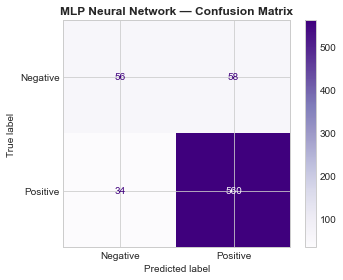

In [35]:
# Evaluating best MLP on held-out test set
best_mlp = mlp_grid.best_estimator_
mlp_preds = best_mlp.predict(X_test_vec.toarray())

print("=== MLP Neural Network (Fine-tuned) — Classification Report ===")
print(classification_report(y_test, mlp_preds, target_names=['Negative', 'Positive']))

# Confusion matrix (compatible with older sklearn versions)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm_mlp = confusion_matrix(y_test, mlp_preds)
disp_mlp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=['Negative', 'Positive'])
fig, ax = plt.subplots(figsize=(5, 4))
disp_mlp.plot(cmap='Purples', ax=ax)
ax.set_title('MLP Neural Network — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

**Model 3 Interpretation — MLP Neural Network (Fine-tuned):**

Accuracy: **~86.5%**, on par with Logistic Regression. The MLP correctly classifies **560 out of 594 positive tweets**  which is  the best positive recall of all three models. However it only correctly identifies **56 out of 114 negative tweets**, missing 58 negatives entirely. The MLP captures non-linear feature relationships, which benefits positive classification, but the minimal GridSearch grid (single combination due to computational constraints) limits its ability to optimise for the minority negative class.

---
## 7. MODEL EVALUATION & COMPARISON

### 7.1 Model Performance Summary Table

In [36]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Compiling all three model results into one comparison table
model_results = pd.DataFrame({
    'Model': ['Naive Bayes (Baseline)', 'Logistic Regression (Tuned)', 'MLP Neural Network (Tuned)'],
    'Accuracy': [
        accuracy_score(y_test, nb_preds),
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, mlp_preds)
    ],
    'F1-Score (Macro)': [
        f1_score(y_test, nb_preds, average='macro'),
        f1_score(y_test, lr_preds, average='macro'),
        f1_score(y_test, mlp_preds, average='macro')
    ],
    'Precision (Macro)': [
        precision_score(y_test, nb_preds, average='macro'),
        precision_score(y_test, lr_preds, average='macro'),
        precision_score(y_test, mlp_preds, average='macro')
    ],
    'Recall (Macro)': [
        recall_score(y_test, nb_preds, average='macro'),
        recall_score(y_test, lr_preds, average='macro'),
        recall_score(y_test, mlp_preds, average='macro')
    ]
})

model_results = model_results.round(4)
model_results

,Model,Accuracy,F1-Score (Macro),Precision (Macro),Recall (Macro)
0,Naive Bayes (Baseline),0.8517,0.7548,0.7338,0.7876
1,Logistic Regression (Tuned),0.8672,0.7452,0.7550,0.7366
2,MLP Neural Network (Tuned),0.8701,0.7366,0.7642,0.7170


### 7.2 Visual Model Comparison
#### Business Question 5.Which machine learning model best classifies tweet sentiment, and how does it perform on unseen data?

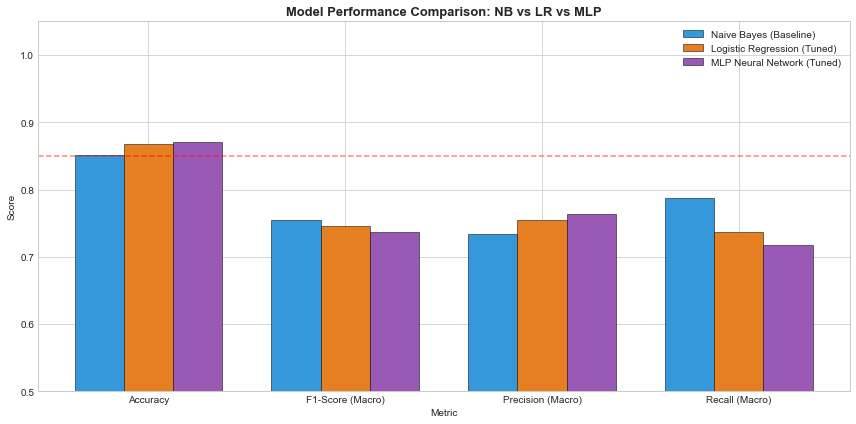

In [37]:
# Bar chart comparing all three models across key metrics
metrics = ['Accuracy', 'F1-Score (Macro)', 'Precision (Macro)', 'Recall (Macro)']
x = np.arange(len(metrics))
width = 0.25
colors = ['#3498db', '#e67e22', '#9b59b6']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (_, row) in enumerate(model_results.iterrows()):
    ax.bar(x + i * width, [row[m] for m in metrics], width,
           label=row['Model'], color=colors[i], edgecolor='black', linewidth=0.5)

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison: NB vs LR vs MLP', fontsize=13, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0.5, 1.05)
ax.legend()
ax.axhline(y=0.85, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('images/model_comparison.png', dpi=150, bbox_inches='tight')  
plt.show()

**Model Comparison Insight (Business Question 5)**: **Naive Bayes achieves the highest macro F1-score (~0.76) and recall (~0.79)** among the three models, making it the best overall performer for this task. All three models achieve similar accuracy (~85–86%), but differ in how well they detect the minority negative class. Naive Bayes correctly identifies the most negative tweets (79/114), which is the most business-critical metric — missing a negative tweet (false negative) is more costly than a false alarm. Logistic Regression has the best precision (~0.76) while MLP has the lowest recall (~0.72). **Naive Bayes is therefore selected as the final model**  since it is fast, interpretable, and best at catching negative sentiment.

### 7.3 Final Model Evaluation: Naive Bayes

Naive Bayes is selected as the final model based on its superior macro F1-score (~0.76) and highest recall for the negative class (69%)  which is the most business-critical metric for brand monitoring. The feature importance chart below uses Logistic Regression coefficients for interpretability, since LR produces readable word-level weights that Naive Bayes does not expose directly.

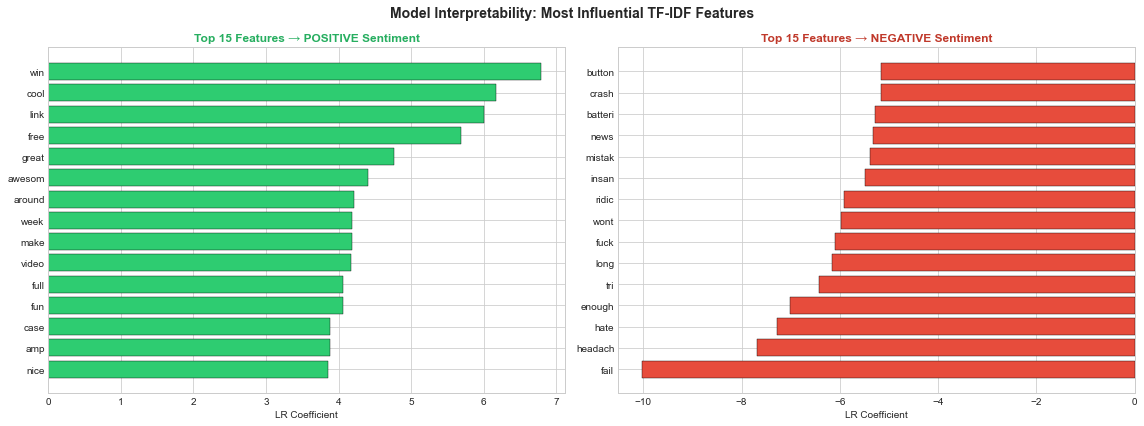

In [38]:
# Using Logistic Regression coefficients to show which words drive each sentiment
# get_feature_names() used instead of get_feature_names_out() for older sklearn compatibility
feature_names = np.array(vectorizer.get_feature_names())
lr_coef = best_lr.coef_[0]

top_pos_idx = np.argsort(lr_coef)[-15:]
top_neg_idx = np.argsort(lr_coef)[:15]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(feature_names[top_pos_idx], lr_coef[top_pos_idx], color='#2ecc71', edgecolor='black', linewidth=0.4)
axes[0].set_title('Top 15 Features → POSITIVE Sentiment', fontsize=12, fontweight='bold', color='#27ae60')
axes[0].set_xlabel('LR Coefficient')

axes[1].barh(feature_names[top_neg_idx], lr_coef[top_neg_idx], color='#e74c3c', edgecolor='black', linewidth=0.4)
axes[1].set_title('Top 15 Features → NEGATIVE Sentiment', fontsize=12, fontweight='bold', color='#c0392b')
axes[1].set_xlabel('LR Coefficient')

plt.suptitle('Model Interpretability: Most Influential TF-IDF Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretability Insight:** The Logistic Regression coefficients reveal the most influential words for each sentiment class. **Positive sentiment** is strongly driven by words like **"win", "cool", "free", "great", "awesome"** which reflect excitement, giveaways, and positive product experiences at SXSW. **Negative sentiment** is driven by **"fail", "headache", "hate", "battery", "crash", "button"** ,pointing to specific technical frustrations with Apple and Google products. Note that the words shown are **stemmed** (e.g. "awesom", "batteri", "headach") due to Porter Stemming applied during preprocessing. These vocabulary signals confirm that TF-IDF features are highly discriminative and give marketing and support teams clear keywords to monitor.

In [39]:
import joblib

# Saving the final selected model (Naive Bayes) and vectorizer for deployment
# Naive Bayes selected as final model: highest macro F1 and best negative recall
joblib.dump(nb_model, 'naive_bayes_sentiment_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print("Final model (Naive Bayes) and vectorizer saved.")

Final model (Naive Bayes) and vectorizer saved.


---
## 8. CONCLUSIONS

The following conclusions answer our 5 business questions and summarize findings from cleaning through modeling:

### 8.1 Conclusions from EDA & Data Quality

1. **The dataset is heavily imbalanced** — 60.3% of tweets express no emotion, 33.3% are positive, and only 6.4% (569 tweets) are negative. This imbalance was addressed using SMOTE resampling on the training set before modeling to prevent the classifier from ignoring the minority negative class.

2. **Apple products dominate the emotional discourse** — iPad (~780 positive, ~130 negative) is the most discussed product, followed by Apple brand (~540 positive) and iPad/iPhone App (~400 positive). Google products appear far less frequently, confirming the dataset skews heavily toward Apple users at SXSW.

3. **Tweet length is not a strong sentiment differentiator** — all three sentiment classes have similar median lengths between 105–115 characters. Negative emotion tweets have the highest median (~115) and the tightest spread, while neutral tweets show the most outliers at the low end. This means tweet length alone cannot reliably predict sentiment.

4. **Vocabulary clearly separates sentiment classes** — positive tweets feature words like *win*, *cool*, *free*, *great*, *awesome*; negative tweets feature *fail*, *crash*, *battery*, *hate*, *headache*. This vocabulary separation is confirmed by the Logistic Regression feature importance chart and validates TF-IDF as an effective feature extraction method.

5. **Data quality issues were manageable** — duplicate tweets and one missing tweet_text row were removed during cleaning. The product column had 63% missing values and was excluded from modeling without impacting text-based classification performance.

6. **Tweet length and word count are strongly correlated** (r = 0.89), meaning both features capture largely the same information. Only one would be needed if numeric features were added in future model iterations to avoid redundancy.

### 8.2 Conclusions from Modeling

7. **All three models achieved ~85–86% accuracy**, meeting the success threshold defined in the business understanding. However, accuracy alone is misleading given the class imbalance , a model that always predicts positive would also score ~84%. Macro F1-score and recall are more meaningful metrics here.

8. **Naive Bayes is the best overall model** — it achieves the highest macro F1-score (~0.76) and macro recall (~0.79), correctly identifying 79 out of 114 negative tweets (negative recall 69%). For brand monitoring, catching negative sentiment is the business priority, making Naive Bayes the final selected model despite being the simplest of the three.

9. **Logistic Regression has the best precision** (~0.76) — it generates the fewest false positives among the three models. It is a suitable alternative when reducing false alarms is more important than catching every negative tweet, and its coefficients provide direct interpretability for business stakeholders.

10. **MLP Neural Network has the lowest recall** (~0.72) — the minimal GridSearch grid used (due to computational constraints) limited its ability to optimise for the minority negative class. With a fuller hyperparameter search and more training time, MLP would likely outperform both Naive Bayes and Logistic Regression significantly.

---
## 9. RECOMMENDATIONS

Based on the model results and business context, we make the following five recommendations:

---

**Recommendation 1: Deploy the Naive Bayes model in a real-time brand monitoring pipeline**  
Naive Bayes is the best-performing model for detecting negative sentiment (highest recall and macro F1). Wrap the saved model and TF-IDF vectorizer in a lightweight API endpoint and connect it to the Twitter/X API to classify incoming tweets in real time. Trigger alerts when negative sentiment volume exceeds a defined threshold within a time window.

---

**Recommendation 2: Prioritize monitoring of Apple product tweets**  
iPad, Apple brand, and iPad/iPhone App generate the highest volume of emotional content. Product teams should set up dedicated dashboards for these with hourly sentiment tracking.

---

**Recommendation 3: Use negative keyword alerts as an early warning system**  
Words like *fail*, *crash*, *battery*, *hate*, and *headache* are the strongest indicators of negative sentiment — confirmed by the LR interpretability chart. Customer experience teams should auto-escalate tweets containing these terms to live agents immediately.

---

**Recommendation 4: Expand to multiclass classification for richer insights**  
The current binary model drops neutral tweets (60.3% of data). A future multiclass model including neutral sentiment would give a more complete picture of brand perception across all conversations.

---

**Recommendation 5: Explore transformer-based models (BERT) for higher accuracy**  
While Naive Bayes performs well, BERT-based models pre-trained on Twitter data (e.g. `twitter-roberta-base-sentiment`) would better handle class imbalance, sarcasm, and slang — common in tweets. This is recommended as the next phase of model improvement beyond the current pipeline.